In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import re
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import OneHotEncoder
from scipy.sparse import hstack
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\laksh\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [2]:
df=pd.read_csv("fake_job_postings.csv")
df.head()

,job_id,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent
0,1,Marketing Intern,"US, NY, New York",Marketing,NaN,"We're Food52, and we've created a groundbreaki...","Food52, a fast-growing, James Beard Award-winn...",Experience with content management systems a m...,NaN,0,1,0,Other,Internship,NaN,NaN,Marketing,0
1,2,Customer Service - Cloud Video Production,"NZ, , Auckland",Success,NaN,"90 Seconds, the worlds Cloud Video Production ...",Organised - Focused - Vibrant - Awesome!Do you...,What we expect from you:Your key responsibilit...,What you will get from usThrough being part of...,0,1,0,Full-time,Not Applicable,NaN,Marketing and Advertising,Customer Service,0
2,3,Commissioning Machinery Assistant (CMA),"US, IA, Wever",NaN,NaN,Valor Services provides Workforce Solutions th...,"Our client, located in Houston, is actively se...",Implement pre-commissioning and commissioning ...,NaN,0,1,0,NaN,NaN,NaN,NaN,NaN,0
3,4,Account Executive - Washington DC,"US, DC, Washington",Sales,NaN,Our passion for improving quality of life thro...,THE COMPANY: ESRI – Environmental Systems Rese...,"EDUCATION: Bachelor’s or Master’s in GIS, busi...",Our culture is anything but corporate—we have ...,0,1,0,Full-time,Mid-Senior level,Bachelor's Degree,Computer Software,Sales,0
4,5,Bill Review Manager,"US, FL, Fort Worth",NaN,NaN,SpotSource Solutions LLC is a Global Human Cap...,JOB TITLE: Itemization Review ManagerLOCATION:...,QUALIFICATIONS:RN license in the State of Texa...,Full Benefits Offered,0,1,1,Full-time,Mid-Senior level,Bachelor's Degree,Hospital & Health Care,Health Care Provider,0


In [3]:
df.isnull().sum()

job_id                     0
title                      0
location                 346
department             11547
salary_range           15012
company_profile         3308
description                1
requirements            2696
benefits                7212
telecommuting              0
has_company_logo           0
has_questions              0
employment_type         3471
required_experience     7050
required_education      8105
industry                4903
function                6455
fraudulent                 0
dtype: int64

In [4]:
df.fillna("", inplace=True)
df.drop(columns=['job_id'], inplace=True)

In [5]:
df.isnull().sum()

title                  0
location               0
department             0
salary_range           0
company_profile        0
description            0
requirements           0
benefits               0
telecommuting          0
has_company_logo       0
has_questions          0
employment_type        0
required_experience    0
required_education     0
industry               0
function               0
fraudulent             0
dtype: int64

In [6]:
df['text'] = (
    df['title'] + " " +
    df['description'] + " " +
    df['requirements'] + " " +
    df['benefits'] + " " +
    df['company_profile']
)

In [7]:
stop_words = set(stopwords.words('english'))
def clean_text(text):
    text = text.lower()
    text = re.sub(r'<.*?>', '', text)  
    text = re.sub(r'[^a-zA-Z]', ' ', text)  
    text = text.split()
    text = [word for word in text if word not in stop_words]
    return " ".join(text)
df['text'] = df['text'].apply(clean_text)

In [8]:
tfidf = TfidfVectorizer(max_features=5000)
X_text = tfidf.fit_transform(df['text'])

In [9]:
binary_cols = ['telecommuting', 'has_company_logo', 'has_questions']
X_binary = df[binary_cols].astype(int)

In [10]:
cat_cols = ['employment_type', 'required_experience', 'required_education',
            'industry', 'function']
X_cat = pd.get_dummies(df[cat_cols])

In [11]:
X_final = hstack([X_text, X_binary, X_cat])

In [12]:
y = df['fraudulent']

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X_final, y, test_size=0.2, random_state=42, stratify=y
)

In [14]:
class_weight = 'balanced'

Accuracy: 0.9653243847874721
Precision: 0.5924528301886792
Recall: 0.9075144508670521
F1 Score: 0.7168949771689498


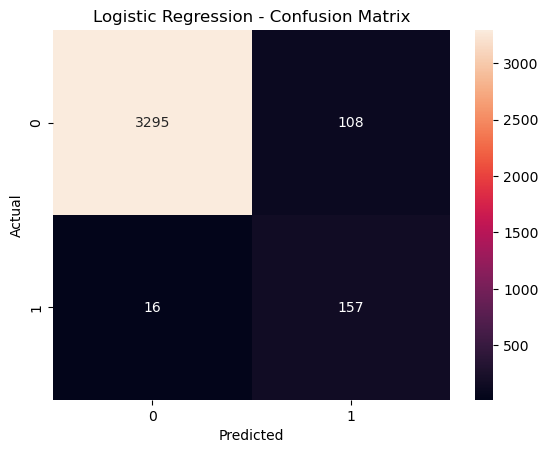

In [15]:
model = LogisticRegression(max_iter=1000, class_weight='balanced')
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Logistic Regression - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Accuracy: 0.9714765100671141
Precision: 0.898876404494382
Recall: 0.4624277456647399
F1 Score: 0.6106870229007634


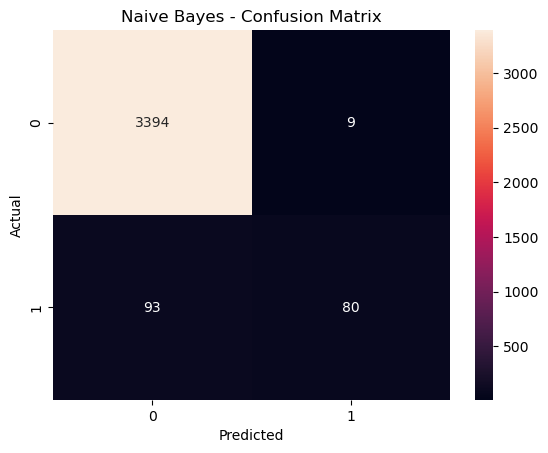

In [16]:
model = MultinomialNB()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Naive Bayes - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Accuracy: 0.9821029082774049
Precision: 0.7914438502673797
Recall: 0.8554913294797688
F1 Score: 0.8222222222222222


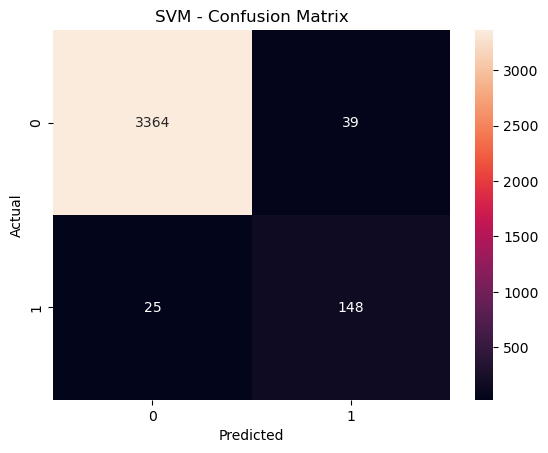

In [17]:
model = LinearSVC(class_weight='balanced')
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d')
plt.title("SVM - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Accuracy: 0.9801454138702461
Precision: 1.0
Recall: 0.5895953757225434
F1 Score: 0.7418181818181818


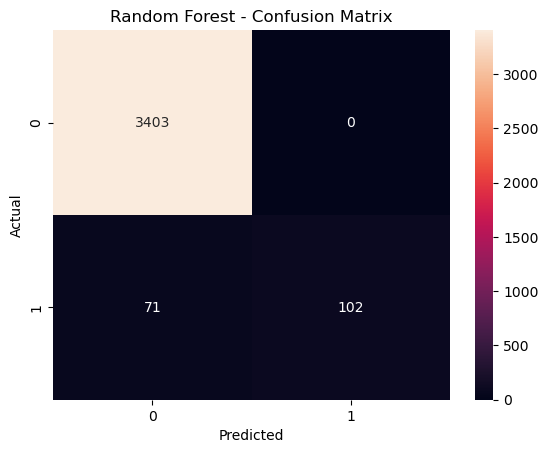

In [18]:
model = RandomForestClassifier(n_estimators=100)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Random Forest - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Accuracy: 0.9854586129753915
Precision: 0.8711656441717791
Recall: 0.8208092485549133
F1 Score: 0.8452380952380952


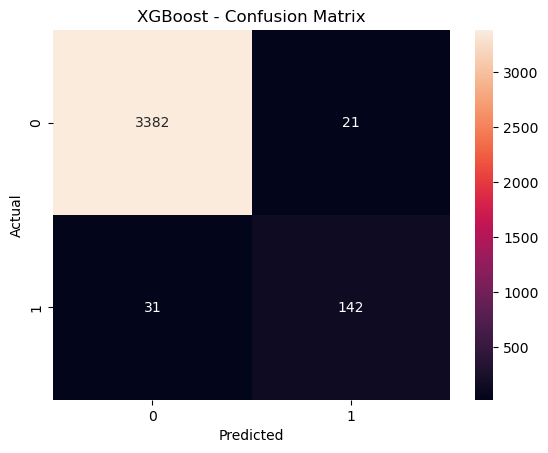

In [19]:
scale_pos_weight = len(y_train[y_train==0]) / len(y_train[y_train==1])
model = XGBClassifier(eval_metric='logloss', scale_pos_weight=scale_pos_weight)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d')
plt.title("XGBoost - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [20]:
model = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1),
    n_estimators=100,
    learning_rate=1.0,
    random_state=42
)

Accuracy: 0.9664429530201343
Precision: 0.9206349206349206
Recall: 0.3352601156069364
F1 Score: 0.4915254237288136


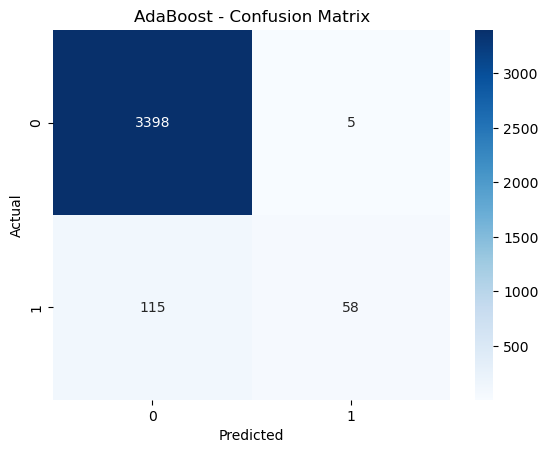

In [21]:
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("AdaBoost - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [22]:
params = {
    'C': [0.01, 0.1, 1, 10]
}
grid = GridSearchCV(
    LogisticRegression(max_iter=1000, class_weight='balanced'),
    param_grid=params,
    cv=3,
    scoring='f1',
    n_jobs=-1
)
grid.fit(X_train, y_train)
best_model = grid.best_estimator_
print("Best Params:", grid.best_params_)

Best Params: {'C': 10}


In [23]:
params = {
    'C': [0.01, 0.1, 1, 10]
}
grid = GridSearchCV(
    LinearSVC(class_weight='balanced'),
    param_grid=params,
    cv=3,
    scoring='f1',
    n_jobs=-1
)
grid.fit(X_train, y_train)
best_model = grid.best_estimator_
print("Best Params:", grid.best_params_)

Best Params: {'C': 10}


In [24]:
params = {
    'n_estimators': [50, 100],
    'max_depth': [None, 10, 20]
}
grid = GridSearchCV(
    RandomForestClassifier(),
    param_grid=params,
    cv=3,
    scoring='f1',
    n_jobs=-1
)
grid.fit(X_train, y_train)
best_model = grid.best_estimator_
print("Best Params:", grid.best_params_)

Best Params: {'max_depth': None, 'n_estimators': 100}


In [26]:
params = {
    'n_estimators': [50, 100],
    'max_depth': [3, 6],
    'learning_rate': [0.01, 0.1]
}
scale_pos_weight = len(y_train[y_train==0]) / len(y_train[y_train==1])
grid = GridSearchCV(
    XGBClassifier(eval_metric='logloss', scale_pos_weight=scale_pos_weight),
    param_grid=params,
    cv=3,
    scoring='f1',
    n_jobs=-1
)
grid.fit(X_train, y_train)
best_model = grid.best_estimator_
print("Best Params:", grid.best_params_)

Best Params: {'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 100}


In [27]:
params = {
    'n_estimators': [50, 100],
    'learning_rate': [0.5, 1.0]
}
grid = GridSearchCV(
    AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=1)),
    param_grid=params,
    cv=3,
    scoring='f1',
    n_jobs=-1
)
grid.fit(X_train, y_train)
best_model = grid.best_estimator_
print("Best Params:", grid.best_params_)

Best Params: {'learning_rate': 1.0, 'n_estimators': 100}


In [28]:
params = {
    'alpha': [0.1, 0.5, 1.0, 2.0]
}
grid = GridSearchCV(
    MultinomialNB(),
    param_grid=params,
    cv=3,
    scoring='f1'
)
grid.fit(X_train, y_train)
print("Best Params:", grid.best_params_)

Best Params: {'alpha': 0.1}


In [29]:
df.to_csv("updated_dataset.csv", index=False)